# 1. Instalasi Library

In [1]:
import os
import re
import glob
import time 
import shutil
import subprocess 
import sys
# import warnings
from collections import Counter

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from IPython.display import display

# warnings.filterwarnings("ignore")
# pd.set_option("display.max_column", 40)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110

SEED = 42
np.random.seed(SEED)
FOLDER_HASIL = "Hasil Perbandingan"
os.makedirs(FOLDER_HASIL, exist_ok=True)

# 2. Konfigurasi

In [2]:
DATASET = "/kaggle/input/datasets/eaganrainmahasin/dataset-inverted-csv"
KOLOM_ID = "docID"
KOLOM_JUDUL = "title"
KOLOM_TEKS = "article_text"
KOLOM_TOKEN = "tokens_stemmed"
MAKS_DOKUMEN = None

K1_BAWAAN = 1.2
B_BAWAAN = 0.75
TOP_K = 10

K_PERCOBAAN = [0.5, 1.2, 2.0, 3.0]
B_PERCOBAAN = [0.0, 0.25, 0.5, 0.75, 1.0]

DAFTAR_QUERY = [
    {"teks": "pendaftaran petugas KPPS Pemilu 2024", "relevan": ["26", "64", "480", "190", "41", "315", "793", "278", "467", "683", "662", "2", "10", "348", "728"]},
    {"teks": "gaji petugas KPPS", "relevan": ["64", "41", "480", "26"]},
    {"teks": "Prabowo naik helikopter TNI ke Marapi", "relevan": ["27", "8"]},
    {"teks": "partai rekomendasi Khofifah cagub Jatim", "relevan": ["55", "78", "221", "846", "30", "12", "60", "874", "863", "335", "871", "870", "147"]},
    {"teks": "laporan dana kampanye parpol", "relevan": ["67", "54", "33"]},
    {"teks": "pengamanan Natal dan Tahun Baru", "relevan": ["3", "489", "437", "474"]},
    {"teks": "panelis dan moderator debat capres", "relevan": ["113", "573", "101", "181", "15", "95", "169", "174", "454", "714", "611"]},
    {"teks": "Gibran kunjungi pondok pesantren", "relevan": ["912", "117", "925", "14", "856", "881", "872", "257"]},
    {"teks": "politik dinasti Ade Armando Jogja", "relevan": ["471", "482", "499", "535", "582", "684", "741", "786", "800", "802", "804", "812", "816", "852", "866", "869", "883", "890", "891", "913", "917", "926", "933", "934", "935", "945", "946"]},
    {"teks": "cek NIK terdaftar anggota parpol", "relevan": ["18"]},
    {"teks": "regulasi kelautan nelayan Ganjar", "relevan": ["29"]},
    {"teks": "daerah rawan pemilu pengamanan polisi", "relevan": ["19"]},
    {"teks": "gugatan pencalonan Gibran", "relevan": ["17"]},
    {"teks": "pemilih muda milenial gen z", "relevan": ["632", "483", "999", "756", "153", "85", "20", "610"]},
]

# 3. Memuat Korpus

In [3]:
#mencari file csv
file_csv = glob.glob('/kaggle/input/**/*.csv', recursive=True)

if file_csv:
    print("file CSV ditemukan:")
    for file in file_csv:
        print(file)
else:
    raise FileNotFoundError("Tidak ada file CSV yang ditemukan!")

path_csv = file_csv[0]

#membaca csv
df = None
for enc in ["utf-8", "utf-8-sig", "latin-1"]:
    try:
        df = pd.read_csv(path_csv, encoding=enc, on_bad_lines="skip")
        break
    except UnicodeDecodeError:
        continue

if df.shape[1]==1:
    df = pd.read_csv(path_csv, encoding=enc, sep=None, engine="python", on_bad_lines="skip")

print("\n", "+="*10, "INFORMASI SKORPUS", "+="*10)
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])
print("Daftar kolom:", df.columns)

display(df.head())

file CSV ditemukan:
/kaggle/input/datasets/eaganrainmahasin/dataset-inverted-csv/dataset_inverted.csv

 +=+=+=+=+=+=+=+=+=+= INFORMASI SKORPUS +=+=+=+=+=+=+=+=+=+=
Jumlah baris: 1000
Jumlah kolom: 4
Daftar kolom: Index(['docID', 'title', 'article_text', 'tokens_stemmed'], dtype='object')


,docID,title,article_text,tokens_stemmed
0,0,Hasto Ingin Debat Pilpres Pertarungan Gagasan dan Tak Ada Rekayasa,Sekjen PDIP sekaligus Sekretaris Tim Pemenang Nasional (TPN) Ganja...,"['sekjen', 'pdip', 'sekaligus', 'sekretaris', 'tim', 'menang', 'na..."
1,1,"Terima Kunjungan Gibran di Ponpes Al-Tsaqafah, Said Aqil Tegaskan ...",Mantan Ketua Umum Pengurus Besar Nahdlatul Ulama (PBNU) Said Aqil ...,"['mantan', 'ketua', 'umum', 'urus', 'besar', 'nahdlatul', 'ulama',..."
2,2,Contoh Format dan Isi Surat Pernyataan Anggota KPPS Pemilu 2024,Surat pernyataan KPPS Pemilu 2024 merupakan bagian dari berkas ata...,"['surat', 'nyata', 'kpps', 'milu', 'rupa', 'bagi', 'berkas', 'doku..."
3,3,9 Ribu Personel Gabungan Dikerahkan Amankan Natal-Tahun Baru di Sumut,Sekitar 9.000 personel dikerahkan untuk mengamankan perayaan Natal...,"['personel', 'kerah', 'aman', 'raya', 'natal', 'tahun', 'baru', 's..."
4,4,Amarah Ukraina Usai Rusia Bakal Gelar Pilpres di Wilayah Pendudukan,"Ukraina marah usai Rusia menjadikan empat wilayahnya, yang kini di...","['ukraina', 'marah', 'usai', 'rusia', 'jadi', 'empat', 'wilayah', ..."


# 4. Pra pemrosesan Query

In [4]:
try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
except ModuleNotFoundError as e:
    if e.name != "Sastrawi":
        raise
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "Sastrawi"
    ])
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer = StemmerFactory().create_stemmer()
stopword_remover = StopWordRemoverFactory()
daftar_stopword = set(stopword_remover.get_stop_words())
    
def case_folding(teks):
    teks = str(teks).lower()
    teks = re.sub(r"[^a-z\s]", " ", teks)
    teks = re.sub(r"\s+", " ", teks).strip()
    return teks

def hapus_stopword(tokens):
    return [kata for kata in tokens if kata not in daftar_stopword]

def stemming(tokens):
    return stemmer.stem(" ".join(tokens)).split()

def praproses(teks_mentah):
    return stemming(hapus_stopword(tokenisasi(case_folding(teks_mentah))))


try:
    import nltk
    from nltk.tokenize import word_tokenize
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)
    word_tokenize("uji coba")
    def tokenisasi(teks):
        return word_tokenize(teks)
except Exception:
    def tokenisasi(teks):
        return teks.split()

stemmer = StemmerFactory().create_stemmer()

print("Contoh praproses query:", praproses("Pendaftaran Petugas KPPS Pemilu 2024!"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.5 MB/s eta 0:00:00
Contoh praproses query: ['daftar', 'tugas', 'kpps', 'milu']


# 5. Implementasi Model 

In [5]:
class IndeksIR:
    def __init__(self, dokumen_token):
        self.N = len(dokumen_token)
        self.kosakata = {}
        baris, kolom, nilai = [], [], []
        for i, token in enumerate(dokumen_token):
            for term, f in Counter(token).items():
                j = self.kosakata.setdefault(term, len(self.kosakata))
                baris.append(i)
                kolom.append(j)
                nilai.append(f)
        V = len(self.kosakata)
        self.tf = sp.csr_matrix((np.array(nilai, dtype=float), (baris, kolom)), shape=(self.N, V))
        self.istilah = [None] * V
        for term, j in self.kosakata.items():
            self.istilah[j] = term
        self.dl = np.asarray(self.tf.sum(axis=1)).ravel()
        self.avgdl = self.dl.mean()
        self.df = np.bincount(self.tf.indices, minlength=V).astype(float)
        self.idf_ltc = np.log10(self.N/self.df)
        self.idf_bm25 = np.log(1.0+(self.N - self.df + 0.5) / (self.df +0.5))
        self.cache_bm25 = {}
        self.bangun_ltc()
    def bangun_ltc(self):
        W = self.tf.copy()
        W.data = 1.0 + np.log10(W.data)
        W = (W @sp.diags(self.idf_ltc)).tocsr()
        self.norma_ltc = np.sqrt(np.asarray(W.power(2).sum(axis=1)).ravel())
        pembagi = np.where(self.norma_ltc>0, self.norma_ltc, 1.0)
        self.W_ltc = (sp.diags(1.0/pembagi)@W).tocsr()
        self.W_ltc_kolom = self.W_ltc.tocsc()

    def hitung_query(self, token_q):
        return Counter(t for t in token_q if t in self.kosakata)

    def vektor_ltc(self, token_q):
        cnt = self.hitung_query(token_q)
        if not cnt:
            return None
        idx = np.array([self.kosakata[t] for t in cnt])
        f = np.array(list(cnt.values()), dtype=float)
        w = (1.0 + np.log10(f)) * self.idf_ltc[idx]
        norma = np.linalg.norm(w)
        if norma == 0:
            return None
        return idx, w/norma

    def skor_tfidf(self, token_q):
        v = self.vektor_ltc(token_q)
        if v is None:
            return np.zeros(self.N)
        idx, w = v
        return np.asarray(self.W_ltc_kolom[:, idx]@w).ravel()

    def matriks_bm25(self, k1, b):
        kunci = (round(float(k1), 6), round(float(b), 6))
        if kunci not in self.cache_bm25:
            K = k1*(1.0 - b + b *self.dl/self.avgdl)
            M = self.tf.copy()
            baris =  np.repeat(np.arange(self.N), np.diff(M.indptr))
            M.data = M.data * (k1 + 1.0)/(M.data + K[baris])
            self.cache_bm25[kunci] = M.tocsc()
        return self.cache_bm25[kunci]

    def skor_bm25(self, token_q, k1=1.2, b=0.75, idf="bm25"):
        cnt = self.hitung_query(token_q)
        if not cnt:
            return np.zeros(self.N)

        idx = np.array([self.kosakata[t] for t in cnt])
        bobot_idf = self.idf_bm25 if idf == "bm25" else self.idf_ltc
        return np.asarray(self.matriks_bm25(k1, b)[:, idx] @ bobot_idf[idx]).ravel()

def peringkat(skor):
    skor =  np.round(skor, 10)
    urut = np.lexsort((np.arange(len(skor)), -skor))
    return urut[skor[urut]>0]

def vektor_peringkat(ranking, n_total):
    r = np.full(n_total, len(ranking) + 1, dtype=float)
    r[ranking] = np.arange(1, len(ranking) + 1)
    return r

# 6. Membangun Index Korpus

,nilai
Jumlah dokumen (N),1000
Ukuran term (V),10688
Total token,257458
avgdl,257.46
dl minimum,14
dl median,228
dl maksimum,2301
Koefisien variasi dl,0.531
Kepadatan matriks tf,1.3261%


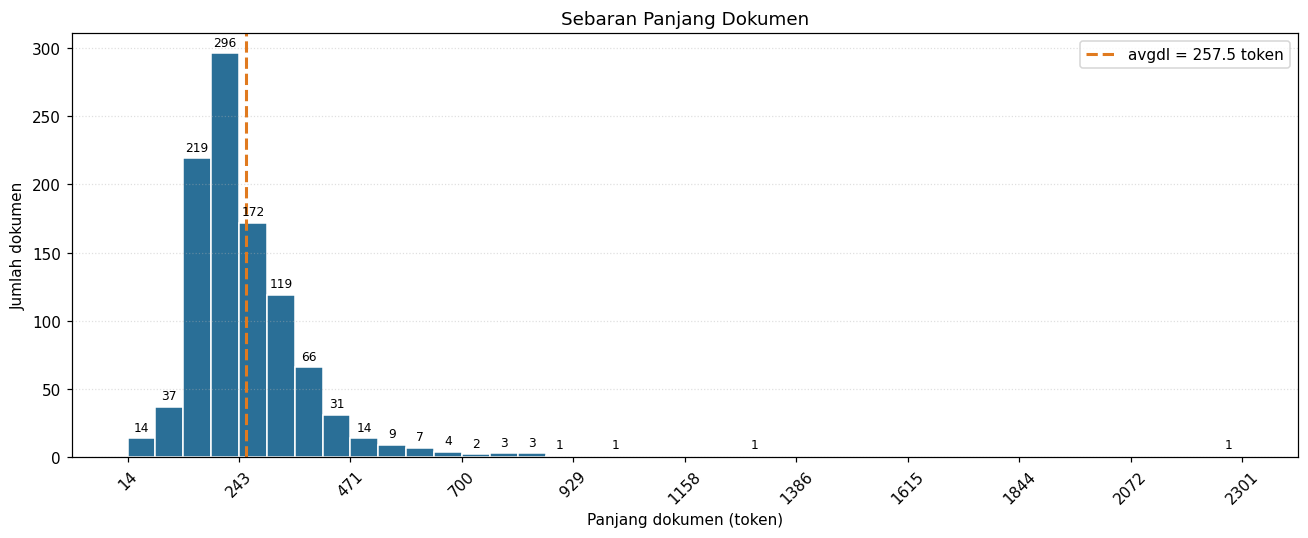

In [6]:
korpus = df[[KOLOM_ID, KOLOM_JUDUL, KOLOM_TEKS, KOLOM_TOKEN]].copy()
korpus.columns = ["id", "judul", "teks", "token_jadi"]
korpus = korpus.dropna(subset=["token_jadi"])

korpus["id"] = korpus["id"].astype(str)
korpus["judul"] = korpus["judul"].fillna("").astype(str)
korpus["token"] = korpus["token_jadi"].apply(lambda s: re.findall(r"[a-z]+", str(s).lower()))
korpus = korpus[korpus["token"].apply(len) > 0].reset_index(drop=True)
judul_kosong = korpus["judul"].str.strip() == ""
korpus["label"] = korpus["judul"].where(~judul_kosong, korpus["teks"].astype(str)).str.slice(0, 60)

token_dokumen = korpus["token"].tolist()
indeks = IndeksIR(token_dokumen)
peta_id = {id_dok: i for i, id_dok in enumerate(korpus["id"])}

ringkasan = pd.Series({
    "Jumlah dokumen (N)": indeks.N,
    "Ukuran term (V)": len(indeks.kosakata),
    "Total token": int(indeks.dl.sum()),
    "avgdl": round(indeks.avgdl, 2),
    "dl minimum": int(indeks.dl.min()),
    "dl median": int(np.median(indeks.dl)),
    "dl maksimum": int(indeks.dl.max()),
    "Koefisien variasi dl": round(indeks.dl.std() / indeks.avgdl, 3),
    "Kepadatan matriks tf": f"{indeks.tf.nnz / (indeks.N * len(indeks.kosakata)):.4%}",
})
display(ringkasan.to_frame("nilai"))

fig, ax = plt.subplots(figsize=(12, 5))

# Membuat histogram
jumlah, batas_bin, patches = ax.hist(
    indeks.dl,
    bins=40,
    color="#2a6f97",
    edgecolor="white"
)

# Menampilkan jumlah dokumen di atas setiap bar
ax.bar_label(
    patches,
    labels=[
        str(int(n)) if n > 0 else ""
        for n in jumlah
    ],
    padding=3,
    fontsize=8
)

# Menampilkan garis rata-rata panjang dokumen
ax.axvline(
    indeks.avgdl,
    color="#e07a1f",
    linestyle="--",
    linewidth=2,
    label=f"avgdl = {indeks.avgdl:.1f} token"
)

# Memperjelas sumbu
ax.set_xlabel("Panjang dokumen (token)")
ax.set_ylabel("Jumlah dokumen")
ax.set_title("Sebaran Panjang Dokumen")

# Menampilkan batas interval pada sumbu X
ax.set_xticks(batas_bin[::4])
ax.tick_params(axis="x", rotation=45)

ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()

fig.savefig(
    f"{FOLDER_HASIL}/sebaran_panjang_dokumen.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

# 7. Pra pemrosesan Query

In [7]:
queries = []
for no, q in enumerate(DAFTAR_QUERY, 1):
    token = praproses(q["teks"])
    relevan_str = [str(r) for r in q["relevan"]]
    hilang = [r for r in relevan_str if r not in peta_id]
    if hilang:
        print(f"Peringatan query {no}: ID relevan tidak ditemukan di korpus -> {hilang}")
    queries.append({
        "no": no,
        "teks": q["teks"],
        "token": token,
        "relevan": {peta_id[r] for r in relevan_str if r in peta_id},
    })

if len(queries) < 10:
    print(f"Peringatan: Query kurang dari 10, total quer: {len(queries)}.")

ringkas_query = pd.DataFrame({
    "no": [q["no"] for q in queries],
    "query": [q["teks"] for q in queries],
    "term terpakai": [", ".join(sorted(indeks.hitung_query(q["token"]))) for q in queries],
    "term di luar kosakata": [", ".join(sorted(set(t for t in q["token"] if t not in indeks.kosakata))) for q in queries],
    "jumlah dok relevan": [len(q["relevan"]) for q in queries],
})
display(ringkas_query)

,no,query,term terpakai,term di luar kosakata,jumlah dok relevan
0,1,pendaftaran petugas KPPS Pemilu 2024,"daftar, kpps, milu, tugas",,15
1,2,gaji petugas KPPS,"gaji, kpps, tugas",,4
2,3,Prabowo naik helikopter TNI ke Marapi,"helikopter, marapi, naik, prabowo, tni",,2
3,4,partai rekomendasi Khofifah cagub Jatim,"cagub, jatim, khofifah, partai, rekomendasi",,13
4,5,laporan dana kampanye parpol,"dana, kampanye, lapor, parpol",,3
5,6,pengamanan Natal dan Tahun Baru,"aman, baru, natal, tahun",,4
6,7,panelis dan moderator debat capres,"capres, debat, moderator, panelis",,11
7,8,Gibran kunjungi pondok pesantren,"gibran, kunjung, pesantren, pondok",,8
8,9,politik dinasti Ade Armando Jogja,"ade, armando, dinasti, jogja, politik",,27
9,10,cek NIK terdaftar anggota parpol,"anggota, cek, daftar, nik, parpol",,1


# 8. Uji Coba Pada Model

In [8]:
SKOR_TFIDF = np.array([indeks.skor_tfidf(q["token"]) for q in queries])
SKOR_BM25 = np.array([indeks.skor_bm25(q["token"], K1_BAWAAN, B_BAWAAN) for q in queries])

RANK_TFIDF = [peringkat(s) for s in SKOR_TFIDF]
RANK_BM25 = [peringkat(s) for s in SKOR_BM25]
RANKV_TFIDF = [vektor_peringkat(r, indeks.N) for r in RANK_TFIDF]
RANKV_BM25 = [vektor_peringkat(r, indeks.N) for r in RANK_BM25]


def tampilkan_top(no, k=TOP_K):
    i = no - 1
    t, m = RANK_TFIDF[i][:k], RANK_BM25[i][:k]
    tabel = pd.DataFrame({
        "peringkat": range(1, k + 1),
        "id (TF-IDF)": pd.Series(korpus["id"].values[t]),
        "dokumen (TF-IDF)": pd.Series(korpus["label"].values[t]),
        "skor cosine": pd.Series(SKOR_TFIDF[i][t]).round(4),
        "id (BM25)": pd.Series(korpus["id"].values[m]),
        "dokumen (BM25)": pd.Series(korpus["label"].values[m]),
        "skor BM25": pd.Series(SKOR_BM25[i][m]).round(4),
    })
    print(f"Query {no}: {queries[i]['teks']!r} | dokumen terambil: TF-IDF={len(RANK_TFIDF[i])}, BM25={len(RANK_BM25[i])}")
    display(tabel)


tampilkan_top(1)

Query 1: 'pendaftaran petugas KPPS Pemilu 2024' | dokumen terambil: TF-IDF=611, BM25=611


,peringkat,id (TF-IDF),dokumen (TF-IDF),skor cosine,id (BM25),dokumen (BM25),skor BM25
0,1,41,Berapa Gaji KPPS Pemilu 2024? Naik 2 Kali Lipat dari 2019!,0.2875,26,Pendaftaran Petugas KPPS Pemilu 2024 Dibuka Besok! Ini Syara,17.4570
1,2,64,Berapa Gaji Petugas KPPS Pemilu 2024? Ini Nominalnya,0.2725,64,Berapa Gaji Petugas KPPS Pemilu 2024? Ini Nominalnya,17.2798
2,3,467,"Perekrutan 28.028 KPPS Makassar, KPU Hindari Calon Punya Pen",0.2690,793,"KPU Klungkung-Gianyar Rekrut Ribuan KPPS Pemilu 2024, Cek Ja",16.6860
3,4,662,"KPU Badung Rekrut 10 Ribu Petugas KPPS, Pendaftaran Mulai 11",0.2567,41,Berapa Gaji KPPS Pemilu 2024? Naik 2 Kali Lipat dari 2019!,16.6304
4,5,683,"KPU Sumsel Buka Pendaftaran KPPS Pemilu 2024, Ini Syaratnya",0.2541,662,"KPU Badung Rekrut 10 Ribu Petugas KPPS, Pendaftaran Mulai 11",16.3620
5,6,128,"Satu Kelurahan di Kupang Didominasi Pengusaha, Enggan Jadi K",0.2330,480,"Cara Daftar KPPS Pemilu 2024: Syarat, Jadwal, dan Gaji",16.2896
6,7,506,Pengertian KPPS Pemilu 2024 Beserta Tugas dan Wewenangnya,0.2295,340,"Pengertian KPPS Pemilu 2024: Tugas, Wewenang, Kewajiban, dan",16.1808
7,8,26,Pendaftaran Petugas KPPS Pemilu 2024 Dibuka Besok! Ini Syara,0.2260,683,"KPU Sumsel Buka Pendaftaran KPPS Pemilu 2024, Ini Syaratnya",16.1430
8,9,793,"KPU Klungkung-Gianyar Rekrut Ribuan KPPS Pemilu 2024, Cek Ja",0.2251,728,"Pastikan Kesehatan Petugas, KPU Bantul Terapkan 2 Syarat Khu",16.0931
9,10,878,Dinkes DKI Minta KPU Wajibkan Anggota KPPS Pemilu Punya BPJS,0.2247,506,Pengertian KPPS Pemilu 2024 Beserta Tugas dan Wewenangnya,15.9769


# 9. Metrik Per Query

In [9]:
def presisi_di_k(ranking, relevan, k):
    return len(set(ranking[:k].tolist()) & relevan) / k

def recall_di_k(ranking, relevan, k):
    return len(set(ranking[:k].tolist()) & relevan) / len(relevan)

def average_precision(ranking, relevan):
    hit, total = 0, 0.0
    for pos, d in enumerate(ranking.tolist(), 1):
        if d in relevan:
            hit += 1
            total += hit / pos
    return total / len(relevan)

def reciprocal_rank(ranking, relevan):
    for pos, d in enumerate(ranking.tolist(), 1):
        if d in relevan:
            return 1.0 / pos
    return 0.0

def hitung_metrik(daftar_ranking):
    baris = []
    for q, r in zip(queries, daftar_ranking):
        if not q["relevan"]:
            continue
        baris.append({
            "no": q["no"],
            f"P@{TOP_K}": presisi_di_k(r, q["relevan"], TOP_K),
            f"R@{TOP_K}": recall_di_k(r, q["relevan"], TOP_K),
            "AP": average_precision(r, q["relevan"]),
            "RR": reciprocal_rank(r, q["relevan"]),
        })
    return pd.DataFrame(baris).set_index("no")

metrik_tfidf = hitung_metrik(RANK_TFIDF)
metrik_bm25 = hitung_metrik(RANK_BM25)
metrik_gabung = pd.concat({"Cosine TF-IDF": metrik_tfidf, "BM25": metrik_bm25}, axis=1)
display(metrik_gabung.round(3))

rata = pd.DataFrame({"Cosine TF-IDF": metrik_tfidf.mean(), "BM25": metrik_bm25.mean()})
rata.index = [f"rata-rata {x}" if x not in ("AP", "RR") else ("MAP" if x == "AP" else "MRR") for x in rata.index]
display(rata.round(3))

unggul_bm25 = int((metrik_bm25["AP"] > metrik_tfidf["AP"] + 1e-9).sum())
unggul_tfidf = int((metrik_tfidf["AP"] > metrik_bm25["AP"] + 1e-9).sum())
print(f"Berdasarkan AP per query: BM25 lebih tinggi pada {unggul_bm25} query, "
      f"TF-IDF lebih tinggi pada {unggul_tfidf} query, seri pada {len(metrik_bm25) - unggul_bm25 - unggul_tfidf} query.")

Cosine TF-IDF                    BM25                   
            P@10   R@10     AP   RR P@10   R@10     AP   RR
no                                                         
1            0.7  0.467  0.827  1.0  0.8  0.533  0.864  1.0
2            0.4  1.000  1.000  1.0  0.4  1.000  1.000  1.0
3            0.2  1.000  1.000  1.0  0.2  1.000  1.000  1.0
4            0.7  0.538  0.822  1.0  0.8  0.615  0.788  1.0
5            0.3  1.000  0.639  0.5  0.3  1.000  1.000  1.0
6            0.3  0.750  0.716  1.0  0.4  1.000  0.725  1.0
7            0.5  0.455  0.545  1.0  0.8  0.727  0.824  1.0
8            0.3  0.375  0.340  0.5  0.4  0.500  0.353  0.5
9            1.0  0.370  0.997  1.0  1.0  0.370  0.990  1.0
10           0.1  1.000  1.000  1.0  0.1  1.000  1.000  1.0
11           0.1  1.000  1.000  1.0  0.1  1.000  1.000  1.0
12           0.1  1.000  0.500  0.5  0.1  1.000  1.000  1.0
13           0.1  1.000  1.000  1.0  0.1  1.000  1.000  1.0
14           0.3  0.375  0.441  1.0  0.6  0.750  0.562  0.5

,Cosine TF-IDF,BM25
rata-rata P@10,0.364,0.436
rata-rata R@10,0.738,0.821
MAP,0.773,0.865
MRR,0.893,0.929


Berdasarkan AP per query: BM25 lebih tinggi pada 7 query, TF-IDF lebih tinggi pada 2 query, seri pada 5 query.


# 10. Perbandingan Peringkat

,query,overlap@10,top-1 sama,spearman,peringkat top-1 BM25 di TF-IDF
no,,,,,
9,politik dinasti Ade Armando Jogja,0.4,False,-0.288,17
12,daerah rawan pemilu pengamanan polisi,0.4,False,-0.171,2
10,cek NIK terdaftar anggota parpol,0.4,True,0.294,1
13,gugatan pencalonan Gibran,0.5,True,0.479,1
8,Gibran kunjungi pondok pesantren,0.6,True,0.024,1
7,panelis dan moderator debat capres,0.6,True,0.064,1
14,pemilih muda milenial gen z,0.6,False,0.481,2
1,pendaftaran petugas KPPS Pemilu 2024,0.7,False,0.198,8
2,gaji petugas KPPS,0.8,False,0.636,2


Rata-rata overlap@10: 0.657 | query dengan top-1 berbeda: 8 dari 14
Korelasi Spearman antara selisih peringkat (TF-IDF - BM25) dan dl/avgdl: 0.570 (n = 188 pasangan)
Kontrol idf: overlap@10 antara BM25 standar dan BM25 ber-idf TF-IDF = 1.000


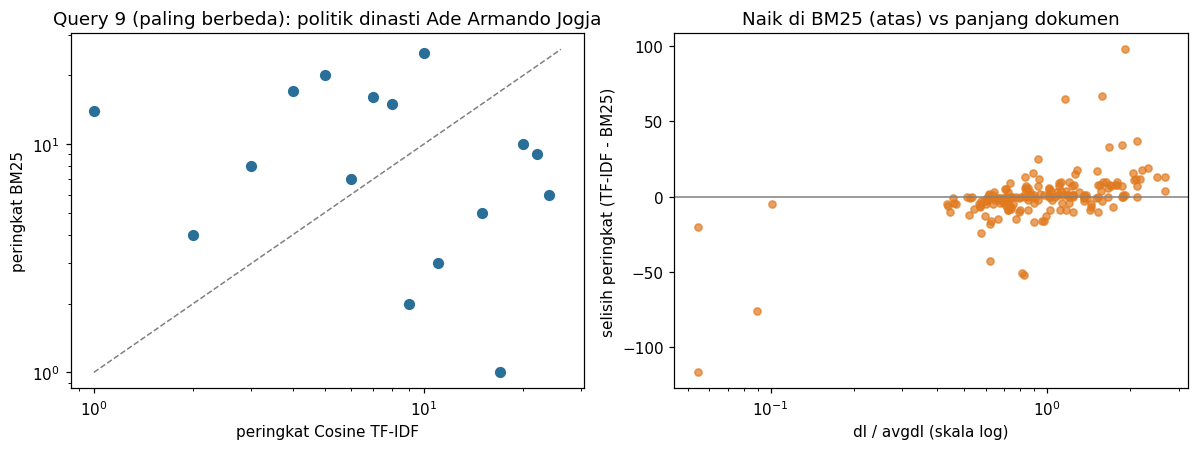

In [10]:
baris_banding = []
catatan_selisih = []
for i, q in enumerate(queries):
    t, m = RANK_TFIDF[i], RANK_BM25[i]
    top_t, top_m = set(t[:TOP_K].tolist()), set(m[:TOP_K].tolist())
    gabungan = np.array(sorted(top_t | top_m), dtype=int)
    rho = np.nan
    if len(gabungan) > 2:
        rho = spearmanr(RANKV_TFIDF[i][gabungan], RANKV_BM25[i][gabungan])[0]
    for d in gabungan:
        catatan_selisih.append((q["no"], d, RANKV_TFIDF[i][d] - RANKV_BM25[i][d], indeks.dl[d] / indeks.avgdl))
    top1_sama = len(t) > 0 and len(m) > 0 and t[0] == m[0]
    baris_banding.append({
        "no": q["no"],
        "query": q["teks"],
        f"overlap@{TOP_K}": len(top_t & top_m) / TOP_K,
        "top-1 sama": bool(top1_sama),
        "spearman": rho,
        "peringkat top-1 BM25 di TF-IDF": int(RANKV_TFIDF[i][m[0]]) if len(m) else np.nan,
    })

banding = pd.DataFrame(baris_banding).set_index("no")
banding_urut = banding.sort_values([f"overlap@{TOP_K}", "spearman"])
display(banding_urut.round(3))
print(f"Rata-rata overlap@{TOP_K}: {banding[f'overlap@{TOP_K}'].mean():.3f} | "
      f"query dengan top-1 berbeda: {int((~banding['top-1 sama']).sum())} dari {len(banding)}")

selisih = pd.DataFrame(catatan_selisih, columns=["no", "dok", "selisih", "rasio_dl"])
if selisih["selisih"].nunique() > 1 and selisih["rasio_dl"].nunique() > 1:
    rho_dl = spearmanr(selisih["selisih"], selisih["rasio_dl"])[0]
    print(f"Korelasi Spearman antara selisih peringkat (TF-IDF - BM25) dan dl/avgdl: {rho_dl:.3f} (n = {len(selisih)} pasangan)")

RANK_BM25_IDF_LTC = [peringkat(indeks.skor_bm25(q["token"], K1_BAWAAN, B_BAWAAN, idf="ltc")) for q in queries]
overlap_kontrol = [len(set(a[:TOP_K].tolist()) & set(b[:TOP_K].tolist())) / TOP_K
                   for a, b in zip(RANK_BM25, RANK_BM25_IDF_LTC)]
print(f"Kontrol idf: overlap@{TOP_K} antara BM25 standar dan BM25 ber-idf TF-IDF = {np.mean(overlap_kontrol):.3f}")

pusat = banding_urut.index[0]
i_pusat = pusat - 1
gabungan_pusat = np.array(sorted(set(RANK_TFIDF[i_pusat][:TOP_K].tolist()) | set(RANK_BM25[i_pusat][:TOP_K].tolist())))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(RANKV_TFIDF[i_pusat][gabungan_pusat], RANKV_BM25[i_pusat][gabungan_pusat], color="#2a6f97", s=40)
batas = max(RANKV_TFIDF[i_pusat][gabungan_pusat].max(), RANKV_BM25[i_pusat][gabungan_pusat].max()) + 1
ax[0].plot([1, batas], [1, batas], color="grey", linestyle="--", linewidth=1)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("peringkat Cosine TF-IDF")
ax[0].set_ylabel("peringkat BM25")
ax[0].set_title(f"Query {pusat} (paling berbeda): {queries[i_pusat]['teks'][:35]}")
ax[1].scatter(selisih["rasio_dl"], selisih["selisih"], color="#e07a1f", s=22, alpha=0.7)
ax[1].axhline(0, color="grey", linewidth=1)
ax[1].set_xscale("log")
ax[1].set_xlabel("dl / avgdl (skala log)")
ax[1].set_ylabel("selisih peringkat (TF-IDF - BM25)")
ax[1].set_title("Naik di BM25 (atas) vs panjang dokumen")
fig.tight_layout()
fig.savefig(f"{FOLDER_HASIL}/perbandingan_peringkat.png", bbox_inches="tight")
plt.show()

# 11. Penyebab Perbedaan Berdasarkan Rumus

In [11]:
def bongkar(no, d, k1=K1_BAWAAN, b=B_BAWAAN):
    q = queries[no - 1]
    cnt = indeks.hitung_query(q["token"])
    vq = indeks.vektor_ltc(q["token"])
    w_q = {int(j): w for j, w in zip(vq[0], vq[1])} if vq is not None else {}
    K = k1 * (1 - b + b * indeks.dl[d] / indeks.avgdl)
    norma = indeks.norma_ltc[d]
    baris = []
    for term in cnt:
        j = indeks.kosakata[term]
        tf = indeks.tf[d, j]
        w_mentah = (1 + np.log10(tf)) * indeks.idf_ltc[j] if tf > 0 else 0.0
        kontribusi_cos = w_q.get(j, 0.0) * w_mentah / norma if norma > 0 else 0.0
        saturasi = tf * (k1 + 1) / (tf + K) if tf > 0 else 0.0
        baris.append({
            "term": term, "tf": int(tf), "df": int(indeks.df[j]),
            "w_dok_mentah": w_mentah, "kontribusi_cosine": kontribusi_cos,
            "idf_bm25": indeks.idf_bm25[j], "saturasi": saturasi,
            "kontribusi_bm25": indeks.idf_bm25[j] * saturasi,
        })
    tabel = pd.DataFrame(baris)
    ringkas = {
        "dl": int(indeks.dl[d]), "dl/avgdl": indeks.dl[d] / indeks.avgdl, "K": K,
        "norma_dok": norma,
        "skor_cosine": tabel["kontribusi_cosine"].sum(), "skor_bm25": tabel["kontribusi_bm25"].sum(),
    }
    assert abs(ringkas["skor_cosine"] - SKOR_TFIDF[no - 1][d]) < 1e-9
    assert abs(ringkas["skor_bm25"] - SKOR_BM25[no - 1][d]) < 1e-9 or (k1, b) != (K1_BAWAAN, B_BAWAAN)
    return tabel, ringkas


def petunjuk(no, d, k1=K1_BAWAAN, b=B_BAWAAN):
    q = queries[no - 1]
    cnt = indeks.hitung_query(q["token"])
    tf_q = {t: indeks.tf[d, indeks.kosakata[t]] for t in cnt}
    cocok = sum(1 for v in tf_q.values() if v > 0)
    tf_maks = max(tf_q.values())
    rasio = indeks.dl[d] / indeks.avgdl
    term_lain = indeks.tf[d].nnz - cocok
    catatan = []
    if rasio >= 1.25:
        catatan.append(f"Dokumen {rasio:.2f}x lebih panjang dari rata-rata: K membesar (b={b}) sehingga saturasi BM25 turun, "
                       "dan norma vektor cosine ikut membesar sehingga semua bobot dibagi lebih besar.")
    elif rasio <= 0.8:
        catatan.append(f"Dokumen hanya {rasio:.2f}x rata-rata: K mengecil sehingga BM25 menaikkan saturasi term yang cocok, "
                       "dan norma cosine kecil sehingga bobot term yang cocok tampak menonjol.")
    else:
        catatan.append(f"Panjang dokumen mendekati rata-rata ({rasio:.2f}x): pengaruh normalisasi panjang kecil, "
                       "perbedaan lebih mungkin berasal dari tf, idf, atau norma cosine.")
    catatan.append(f"{cocok} dari {len(cnt)} term query ada di dokumen ini.")
    if tf_maks >= 3:
        catatan.append(f"tf tertinggi untuk term query = {int(tf_maks)}: BM25 menjenuh mendekati k1+1={k1 + 1:.1f}, "
                       "sedangkan 1+log10(tf) terus tumbuh walau melambat.")
    if indeks.norma_ltc[d] > 1.3 * np.median(indeks.norma_ltc):
        catatan.append(f"Ada {term_lain} term lain di dokumen yang memperbesar norma cosine ({indeks.norma_ltc[d]:.2f} vs median "
                       f"{np.median(indeks.norma_ltc):.2f}) tetapi tidak dihitung BM25.")
    return catatan


def pilih_kontras(no):
    i = no - 1
    gabungan = np.array(sorted(set(RANK_TFIDF[i][:TOP_K].tolist()) | set(RANK_BM25[i][:TOP_K].tolist())), dtype=int)
    if len(gabungan) == 0:
        return None
    delta = RANKV_TFIDF[i][gabungan] - RANKV_BM25[i][gabungan]
    return gabungan[np.argmax(delta)], gabungan[np.argmin(delta)], delta.max(), delta.min()


def analisis_query(no):
    hasil = pilih_kontras(no)
    print("=" * 100)
    print(f"QUERY {no}: {queries[no - 1]['teks']!r} (term terpakai: {sorted(indeks.hitung_query(queries[no - 1]['token']))})")
    if hasil is None or (hasil[2] == 0 and hasil[3] == 0):
        print("Peringkat kedua model identik pada query ini, tidak ada dokumen kontras.")
        return
    d_bm25, d_tfidf, g_bm25, g_tfidf = hasil
    for judul, d, g in [("Dokumen yang NAIK di BM25 dibanding TF-IDF", d_bm25, g_bm25),
                        ("Dokumen yang NAIK di TF-IDF dibanding BM25", d_tfidf, -g_tfidf)]:
        tabel, ringkas = bongkar(no, d)
        print("-" * 100)
        print(f"{judul}: id={korpus['id'][d]} | {korpus['label'][d]}")
        print(f"peringkat TF-IDF = {int(RANKV_TFIDF[no - 1][d])}, peringkat BM25 = {int(RANKV_BM25[no - 1][d])}, selisih = {abs(g):.0f}")
        print("  ".join(f"{k}={v:.3f}" if isinstance(v, float) else f"{k}={v}" for k, v in ringkas.items()))
        display(tabel.round(4))
        for c in petunjuk(no, d):
            print("  -", c)


for no_pilih in banding_urut.index[:2]:
    analisis_query(no_pilih)

QUERY 9: 'politik dinasti Ade Armando Jogja' (term terpakai: ['ade', 'armando', 'dinasti', 'jogja', 'politik'])
----------------------------------------------------------------------------------------------------
Dokumen yang NAIK di BM25 dibanding TF-IDF: id=802 | Kala PSI DIY Tepis Ade Armando, Minta Keistimewaan Jogja Dih
peringkat TF-IDF = 24, peringkat BM25 = 6, selisih = 18
dl=570  dl/avgdl=2.214  K=2.293  norma_dok=24.401  skor_cosine=0.250  skor_bm25=26.700


,term,tf,df,w_dok_mentah,kontribusi_cosine,idf_bm25,saturasi,kontribusi_bm25
0,politik,11,316,1.0213,0.0069,1.1514,1.8206,2.0963
1,dinasti,10,35,2.9119,0.0576,3.3392,1.7897,5.9762
2,ade,17,39,3.1426,0.0602,3.2325,1.9386,6.2663
3,armando,9,28,3.0346,0.0641,3.5589,1.7534,6.2400
4,jogja,9,30,2.9761,0.0616,3.4910,1.7534,6.1211


  - Dokumen 2.21x lebih panjang dari rata-rata: K membesar (b=0.75) sehingga saturasi BM25 turun, dan norma vektor cosine ikut membesar sehingga semua bobot dibagi lebih besar.
  - 5 dari 5 term query ada di dokumen ini.
  - tf tertinggi untuk term query = 17: BM25 menjenuh mendekati k1+1=2.2, sedangkan 1+log10(tf) terus tumbuh walau melambat.
  - Ada 246 term lain di dokumen yang memperbesar norma cosine (24.40 vs median 17.05) tetapi tidak dihitung BM25.
----------------------------------------------------------------------------------------------------
Dokumen yang NAIK di TF-IDF dibanding BM25: id=471 | Kaesang Ingatkan Keluar dari PSI Jika Tak Taat, Ini Kata Ade
peringkat TF-IDF = 10, peringkat BM25 = 25, selisih = 15
dl=172  dl/avgdl=0.668  K=0.901  norma_dok=13.239  skor_cosine=0.297  skor_bm25=20.977


,term,tf,df,w_dok_mentah,kontribusi_cosine,idf_bm25,saturasi,kontribusi_bm25
0,politik,3,316,0.7390,0.0093,1.1514,1.6918,1.9479
1,dinasti,3,35,2.1506,0.0785,3.3392,1.6918,5.6492
2,ade,11,39,2.8762,0.1016,3.2325,2.0334,6.5729
3,armando,6,28,2.7612,0.1074,3.5589,1.9127,6.8070
4,jogja,0,30,0.0000,0.0000,3.4910,0.0000,0.0000


  - Dokumen hanya 0.67x rata-rata: K mengecil sehingga BM25 menaikkan saturasi term yang cocok, dan norma cosine kecil sehingga bobot term yang cocok tampak menonjol.
  - 4 dari 5 term query ada di dokumen ini.
  - tf tertinggi untuk term query = 11: BM25 menjenuh mendekati k1+1=2.2, sedangkan 1+log10(tf) terus tumbuh walau melambat.
QUERY 12: 'daerah rawan pemilu pengamanan polisi' (term terpakai: ['aman', 'daerah', 'milu', 'polisi', 'rawan'])
----------------------------------------------------------------------------------------------------
Dokumen yang NAIK di BM25 dibanding TF-IDF: id=851 | Bey Machmudin Lantik 2 Pj Kepala Daerah di Jabar
peringkat TF-IDF = 21, peringkat BM25 = 5, selisih = 16
dl=229  dl/avgdl=0.889  K=1.101  norma_dok=19.374  skor_cosine=0.083  skor_bm25=9.648


,term,tf,df,w_dok_mentah,kontribusi_cosine,idf_bm25,saturasi,kontribusi_bm25
0,daerah,6,277,0.9914,0.0159,1.2829,1.8590,2.3850
1,rawan,2,120,1.1980,0.0316,2.1171,1.4191,3.0044
2,milu,3,569,0.3617,0.0025,0.5640,1.6096,0.9078
3,aman,4,143,1.3532,0.0328,1.9424,1.7253,3.3513
4,polisi,0,72,0.0000,0.0000,2.6252,0.0000,0.0000


  - Panjang dokumen mendekati rata-rata (0.89x): pengaruh normalisasi panjang kecil, perbedaan lebih mungkin berasal dari tf, idf, atau norma cosine.
  - 4 dari 5 term query ada di dokumen ini.
  - tf tertinggi untuk term query = 6: BM25 menjenuh mendekati k1+1=2.2, sedangkan 1+log10(tf) terus tumbuh walau melambat.
----------------------------------------------------------------------------------------------------
Dokumen yang NAIK di TF-IDF dibanding BM25: id=451 | Kabaharkam: Pemilu Damai, Aman dan Sejuk Jadi Pondasi Kita B
peringkat TF-IDF = 1, peringkat BM25 = 118, selisih = 117
dl=14  dl/avgdl=0.054  K=0.349  norma_dok=2.807  skor_cosine=0.159  skor_bm25=4.279


,term,tf,df,w_dok_mentah,kontribusi_cosine,idf_bm25,saturasi,kontribusi_bm25
0,daerah,0,277,0.0000,0.0000,1.2829,0.0000,0.0000
1,rawan,0,120,0.0000,0.0000,2.1171,0.0000,0.0000
2,milu,3,569,0.3617,0.0175,0.5640,1.9708,1.1115
3,aman,1,143,0.8447,0.1412,1.9424,1.6309,3.1679
4,polisi,0,72,0.0000,0.0000,2.6252,0.0000,0.0000


  - Dokumen hanya 0.05x rata-rata: K mengecil sehingga BM25 menaikkan saturasi term yang cocok, dan norma cosine kecil sehingga bobot term yang cocok tampak menonjol.
  - 2 dari 5 term query ada di dokumen ini.
  - tf tertinggi untuk term query = 3: BM25 menjenuh mendekati k1+1=2.2, sedangkan 1+log10(tf) terus tumbuh walau melambat.


# 12. Pengaruh K_1 dan b

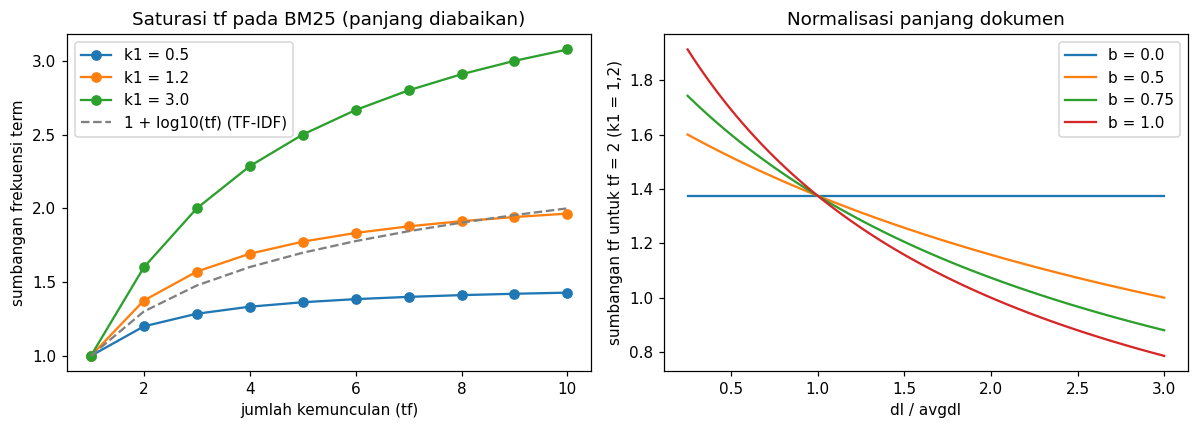

,k1,b,overlap@10,query top-1 berubah,MAP,P@10
0,0.5,0.00,0.821,4,0.857,0.414
1,0.5,0.25,0.871,4,0.862,0.414
2,0.5,0.50,0.893,1,0.859,0.421
3,0.5,0.75,0.907,0,0.857,0.421
4,0.5,1.00,0.879,1,0.856,0.421
5,1.2,0.00,0.893,4,0.856,0.421
6,1.2,0.25,0.936,4,0.863,0.421
7,1.2,0.50,0.943,2,0.867,0.429
8,1.2,0.75,1.000,0,0.865,0.436
9,1.2,1.00,0.943,1,0.866,0.436


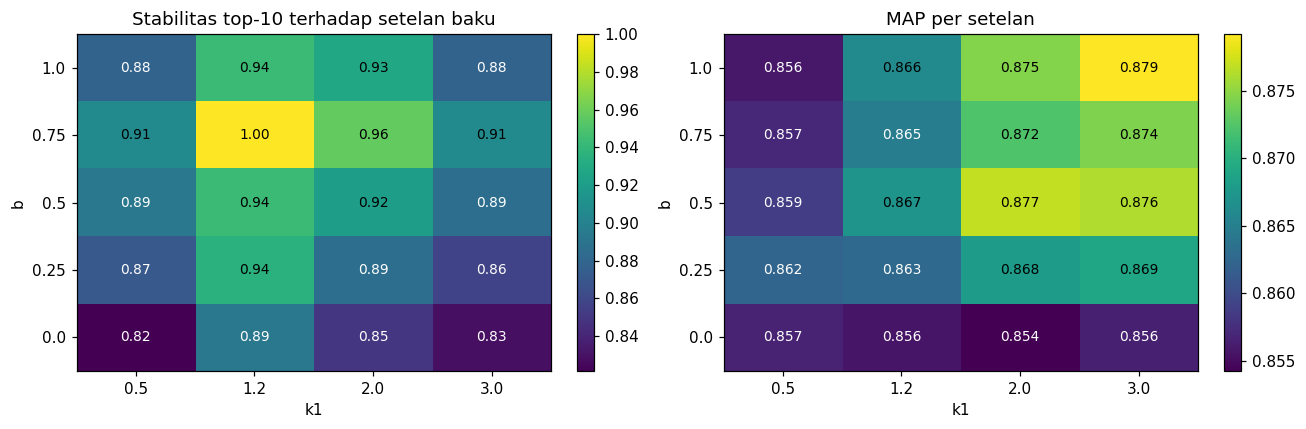

Sensitivitas per query (dari 20 setelan):


,query,setelan yang mengubah top-k,overlap@10 terendah,setelan terburuk
no,,,,
10,cek NIK terdaftar anggota parpol,17,0.4,"(0.5, 0.0)"
13,gugatan pencalonan Gibran,14,0.5,"(3.0, 1.0)"
8,Gibran kunjungi pondok pesantren,18,0.6,"(0.5, 0.0)"
11,regulasi kelautan nelayan Ganjar,12,0.6,"(0.5, 0.0)"
12,daerah rawan pemilu pengamanan polisi,18,0.7,"(0.5, 0.0)"
9,politik dinasti Ade Armando Jogja,16,0.7,"(3.0, 1.0)"
3,Prabowo naik helikopter TNI ke Marapi,17,0.8,"(0.5, 0.0)"
2,gaji petugas KPPS,12,0.8,"(0.5, 0.0)"
7,panelis dan moderator debat capres,10,0.8,"(0.5, 0.0)"


Jejak peringkat 5 dokumen teratas BM25 baku untuk query 10 ('cek NIK terdaftar anggota parpol'):


,"k1=0.5, b=0.75","k1=1.2, b=0.75","k1=2.0, b=0.75","k1=3.0, b=0.75","k1=1.2, b=0.0","k1=1.2, b=0.25","k1=1.2, b=0.5","k1=1.2, b=1.0"
18 | Cara Cek NIK Terdaftar Parpol Pemil,1,1,1,1,1,1,1,1
190 | KPU Tana Toraja Buka Lowongan Kerja,2,2,2,2,2,2,2,2
444 | Kris Dayanti Soroti Daftar Caleg Ta,3,3,3,6,3,3,3,4
"502 | Berstatus Polisi Aktif, Caleg PDIP",4,4,9,17,17,12,5,3
662 | KPU Badung Rekrut 10 Ribu Petugas K,8,5,10,15,16,15,12,5


In [12]:
tf_sumbu = np.arange(1, 11)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for k1 in [0.5, 1.2, 3.0]:
    ax[0].plot(tf_sumbu, tf_sumbu * (k1 + 1) / (tf_sumbu + k1), marker="o", label=f"k1 = {k1}")
ax[0].plot(tf_sumbu, 1 + np.log10(tf_sumbu), linestyle="--", color="grey", label="1 + log10(tf) (TF-IDF)")
ax[0].set_xlabel("jumlah kemunculan (tf)")
ax[0].set_ylabel("sumbangan frekuensi term")
ax[0].set_title("Saturasi tf pada BM25 (panjang diabaikan)")
ax[0].legend()
rasio_sumbu = np.linspace(0.25, 3, 100)
for b in [0.0, 0.5, 0.75, 1.0]:
    K = 1.2 * (1 - b + b * rasio_sumbu)
    ax[1].plot(rasio_sumbu, 2 * 2.2 / (2 + K), label=f"b = {b}")
ax[1].set_xlabel("dl / avgdl")
ax[1].set_ylabel("sumbangan tf untuk tf = 2 (k1 = 1,2)")
ax[1].set_title("Normalisasi panjang dokumen")
ax[1].legend()
fig.tight_layout()
fig.savefig(f"{FOLDER_HASIL}/kurva_teori_k1_b.png", bbox_inches="tight")
plt.show()

SETELAN = sorted({(k1, b) for k1 in K_PERCOBAAN for b in B_PERCOBAAN} | {(K1_BAWAAN, B_BAWAAN)})
RANK_GRID = {s: [peringkat(indeks.skor_bm25(q["token"], s[0], s[1])) for q in queries] for s in SETELAN}
dasar = RANK_GRID[(K1_BAWAAN, B_BAWAAN)]

baris_grid = []
overlap_per_query = {}
for (k1, b), rk in RANK_GRID.items():
    ov = [len(set(r[:TOP_K].tolist()) & set(d[:TOP_K].tolist())) / TOP_K for r, d in zip(rk, dasar)]
    overlap_per_query[(k1, b)] = ov
    top1_beda = sum(1 for r, d in zip(rk, dasar) if len(r) and len(d) and r[0] != d[0])
    ada_nilai = [(r, q["relevan"]) for r, q in zip(rk, queries) if q["relevan"]]
    baris_grid.append({
        "k1": k1, "b": b, f"overlap@{TOP_K}": np.mean(ov), "query top-1 berubah": top1_beda,
        "MAP": np.mean([average_precision(r, rel) for r, rel in ada_nilai]) if ada_nilai else np.nan,
        f"P@{TOP_K}": np.mean([presisi_di_k(r, rel, TOP_K) for r, rel in ada_nilai]) if ada_nilai else np.nan,
    })

grid = pd.DataFrame(baris_grid)
display(grid.round(3))


def gambar_heatmap(ax, kolom, judul, fmt):
    tabel = grid.pivot(index="b", columns="k1", values=kolom)
    im = ax.imshow(tabel.values, cmap="viridis", aspect="auto", origin="lower")
    ax.set_xticks(range(len(tabel.columns)))
    ax.set_xticklabels(tabel.columns)
    ax.set_yticks(range(len(tabel.index)))
    ax.set_yticklabels(tabel.index)
    ax.set_xlabel("k1")
    ax.set_ylabel("b")
    ax.set_title(judul)
    nilai_tengah = np.nanmean(tabel.values)
    for a in range(tabel.shape[0]):
        for c in range(tabel.shape[1]):
            v = tabel.values[a, c]
            ax.text(c, a, format(v, fmt), ha="center", va="center",
                    color="white" if v < nilai_tengah else "black", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)


fig, ax = plt.subplots(1, 2, figsize=(12, 4))
gambar_heatmap(ax[0], f"overlap@{TOP_K}", f"Stabilitas top-{TOP_K} terhadap setelan baku", ".2f")
gambar_heatmap(ax[1], "MAP", "MAP per setelan", ".3f")
fig.tight_layout()
fig.savefig(f"{FOLDER_HASIL}/heatmap_grid_k1_b.png", bbox_inches="tight")
plt.show()

sens = pd.DataFrame({
    "no": [q["no"] for q in queries],
    "query": [q["teks"] for q in queries],
    "setelan yang mengubah top-k": [sum(1 for s in SETELAN if overlap_per_query[s][i] < 1) for i in range(len(queries))],
    f"overlap@{TOP_K} terendah": [min(overlap_per_query[s][i] for s in SETELAN) for i in range(len(queries))],
    "setelan terburuk": [min(SETELAN, key=lambda s: overlap_per_query[s][i]) for i in range(len(queries))],
}).set_index("no").sort_values([f"overlap@{TOP_K} terendah", "setelan yang mengubah top-k"], ascending=[True, False])
print(f"Sensitivitas per query (dari {len(SETELAN)} setelan):")
display(sens)

SETELAN_JALUR = list(dict.fromkeys([(k, B_BAWAAN) for k in K_PERCOBAAN] + [(K1_BAWAAN, b) for b in B_PERCOBAAN if b != B_BAWAAN]))
no_peka = sens.index[0]
i_peka = no_peka - 1
dok_dasar = dasar[i_peka][:5]


def posisi(ranking, d):
    daftar = ranking[:100].tolist()
    return daftar.index(d) + 1 if d in daftar else ">100"


jejak = pd.DataFrame(
    {f"k1={k1}, b={b}": [posisi(RANK_GRID[(k1, b)][i_peka], d) for d in dok_dasar] for k1, b in SETELAN_JALUR},
    index=[f"{korpus['id'][d]} | {korpus['label'][d][:35]}" for d in dok_dasar],
)
print(f"Jejak peringkat 5 dokumen teratas BM25 baku untuk query {no_peka} ({queries[i_peka]['teks']!r}):")
display(jejak)

In [13]:
ringkas_query.to_csv(f"{FOLDER_HASIL}/query_uji.csv", index=False)
metrik_gabung.to_csv(f"{FOLDER_HASIL}/metrik_per_query.csv")
banding_urut.to_csv(f"{FOLDER_HASIL}/perbandingan_peringkat_per_query.csv")
grid.to_csv(f"{FOLDER_HASIL}/grid_k1_b.csv", index=False)
sens.to_csv(f"{FOLDER_HASIL}/sensitivitas_per_query.csv")
jejak.to_csv(f"{FOLDER_HASIL}/jejak_peringkat.csv")

shutil.make_archive(FOLDER_HASIL, "zip", FOLDER_HASIL)
print("Berkas yang dihasilkan:")
for nama in sorted(os.listdir(FOLDER_HASIL)):
    print(" -", os.path.join(FOLDER_HASIL, nama))
print(f" - {FOLDER_HASIL}.zip")

Berkas yang dihasilkan:
 - Hasil Perbandingan/grid_k1_b.csv
 - Hasil Perbandingan/heatmap_grid_k1_b.png
 - Hasil Perbandingan/jejak_peringkat.csv
 - Hasil Perbandingan/kurva_teori_k1_b.png
 - Hasil Perbandingan/metrik_per_query.csv
 - Hasil Perbandingan/perbandingan_peringkat.png
 - Hasil Perbandingan/perbandingan_peringkat_per_query.csv
 - Hasil Perbandingan/query_uji.csv
 - Hasil Perbandingan/sebaran_panjang_dokumen.png
 - Hasil Perbandingan/sensitivitas_per_query.csv
 - Hasil Perbandingan.zip
